# **LAB 12**

## **Esercizio 12.1**

In questo esercizio viene affrontato un problema di classificazione supervisionata basato sul dataset MNIST, costituito da immagini in scala di grigi raffiguranti cifre scritte a mano (da 0 a 9). L’obiettivo è la costruzione e l’addestramento di una rete neurale artificiale in grado di riconoscere correttamente la cifra presente in ciascuna immagine.

Un aspetto centrale di questo esercizio è il confronto tra diversi algoritmi di ottimizzazione (ovvero algoritmi che regolano il processo di aggiornamento dei pesi all'interno della rete neurale), mantenendo invariata l’architettura della rete e la funzione di perdita. In particolare, vengono analizzati gli ottimizzatori SGD, Adam, RMSprop e Adagrad, al fine di studiarne l’impatto sulle prestazioni del modello in termini di accuratezza e velocità di convergenza.

#### STEP 1: Caricamento ed elaborazione dei dati
Innanzitutto vengono importate le librerie necessarie e vengono inizializzati i generatori di numeri casuali. L’impostazione del seed garantisce la riproducibilità degli esperimenti, facendo in modo che l’estrazione casuale dei dati e l’inizializzazione della rete producano sempre gli stessi risultati a ogni esecuzione del codice.

In [2]:
import tensorflow as tf
from tensorflow import keras
import os
import numpy as np
import matplotlib.pyplot as plt
seed=0
np.random.seed(seed) # fix random seed 
tf.random.set_seed(seed)

Viene poi caricato il dataset MNIST. Le immagini hanno dimensione 28×28 pixel, mentre il numero di classi è pari a 10, corrispondente alle cifre da 0 a 9. Il dataset viene suddiviso automaticamente in un insieme di addestramento (X_train, Y_train) e uno di test (X_test, Y_test).

In [3]:
from keras.datasets import mnist

# input image dimensions
img_rows, img_cols = 28, 28 # number of pixels 
# output
num_classes = 10 # 10 digits

# the data, split between train and test sets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)

X_train shape: (60000, 28, 28)
Y_train shape: (60000,)


Successivamente viene effettuato il preprocessing dei dati prima dell’addestramento della rete neurale. Le immagini del dataset vengono prima trasformate da matrici 28×28 in vettori monodimensionali di 784 pixel, così da poter essere utilizzate come input della rete. Successivamente i valori vengono convertiti in formato float32 e normalizzati nell’intervallo $[0,1]$, in modo da migliorare la stabilità e l’efficienza dell’addestramento.

Le etichette vengono convertite nel formato one-hot encoding tramite `to_categorical`: ogni cifra viene rappresentata da un vettore binario di lunghezza 10, necessario per utilizzare la funzione di perdita categorical_crossentropy nella classificazione multiclasse.

In [38]:
# reshape data, it could depend on Keras backend
X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print()

# cast to floats
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# rescale data in interval [0,1]
X_train /= 255
X_test /= 255


# convert class vectors to binary class matrices, e.g. for use with categorical_crossentropy
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)

X_train shape: (60000, 784)
X_test shape: (10000, 784)



#### STEP 2: Creazione della rete neurale

Viene definita la funzione `create_DNN()`, utilizzata per costruire una rete neurale profonda (Deep Neural Network) tramite l’API Sequential di Keras.
Il modello è composto da una sequenza di layer completamente connessi (Dense layers), nei quali ogni neurone è collegato a tutti quelli del livello successivo.

L’input della rete è costituito dalle immagini del dataset MNIST trasformate in vettori di 784 pixel. La rete contiene due layer nascosti con funzione di attivazione ReLU, rispettivamente da 400 e 100 neuroni, che permettono di apprendere relazioni non lineari nei dati. Successivamente viene applicato un layer di Dropout con probabilità 0.5, utile per ridurre il rischio di overfitting disattivando casualmente alcuni neuroni durante l’addestramento.

Il layer di output utilizza la funzione di attivazione softmax e contiene 10 neuroni, uno per ciascuna possibile cifra da classificare. Questo permette alla rete di restituire una distribuzione di probabilità sulle diverse classi.

In [39]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

def create_DNN():
    # instantiate model
    model = Sequential()
    model.add(Input(shape=(img_rows*img_cols,)))
    # add a dense all-to-all relu layer
    model.add(Dense(400, activation='relu'))
    # add a dense all-to-all relu layer
    model.add(Dense(100, activation='relu'))
    # apply dropout with rate 0.5
    model.add(Dropout(0.5))
    # soft-max layer
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

print('Model architecture created successfully!')

Model architecture created successfully!


#### STEP 3: Scelta dell'ottimizzatore e della funzione Loss

Viene poi definita la funzione `compile_model()`, che prepara la rete neurale per l’addestramento. Innanzittutto viene richiamata la funzione `create_DNN()` per costruire il modello, poi questo viene compilato tramite il metodo `compile()`, che specifica tutti gli elementi necessari per il training.

Viene utilizzata la funzione di perdita `categorical_crossentropy`, adatta a problemi di classificazione multiclasse come quello del MNIST. 


Come già accennato, l'obiettivo di questo esercizio è quello di confrontare le prestazioni di diversi algoritmi di ottimizzazione, mantenendo invariata l’architettura della rete e la funzione di loss. Si vuole infatti valutare come la scelta dell'ottimizzazione influenzi la velocità di convergenza, la stabilità del training e le prestazioni finali sul test set. Gli ottimizzatori utilizzati nell'esperimento sono: 


- **SGD (Stochastic Gradient Descent)**: rappresenta il metodo più semplice e tradizionale per l’ottimizzazione di reti neurali. L’idea di base consiste nell’aggiornare i pesi del modello seguendo la direzione di discesa del gradiente della funzione di perdita.

- **Adam**: si tratta di un ottimizzatore adattivo, ovvero è in grado di regolare dinamicamente l’entità degli aggiornamenti dei pesi in base a ciò che sta succedendo durante il training. In particolare, l’ottimizzatore Adam non utilizza direttamente il gradiente calcolato a ogni iterazione, ma costruisce due stime progressive nel tempo basate sui gradienti osservati durante il training. La prima è una media mobile dei gradienti, che rappresenta una sorta di “direzione media” seguita dal modello nel tempo. Questa componente serve a stabilizzare gli aggiornamenti, riducendo le oscillazioni casuali del gradiente. La seconda è una media mobile dei gradienti quadratici (cioè dei valori del gradiente elevati al quadrato), che misura quanto i gradienti variano in ampiezza. Questa informazione viene utilizzata per capire se un parametro sta subendo aggiornamenti grandi e instabili oppure piccoli e regolari. Combinando queste due informazioni, Adam è in grado di modulare automaticamente la dimensione del passo di aggiornamento per ciascun parametro: aggiornamenti più piccoli quando i gradienti sono instabili o molto grandi, e aggiornamenti più efficaci quando la direzione di apprendimento è più stabile.

- **RMSprop**: è un ottimizzatore adattivo che modifica il learning rate in funzione della media recente dei gradienti. L’obiettivo principale è ridurre l’effetto delle oscillazioni nei gradienti, normalizzando gli aggiornamenti dei pesi. Questo lo rende particolarmente efficace in problemi caratterizzati da gradienti rumorosi o non stazionari.

- **Adagrad**: è un ottimizzatore adattivo che adatta individualmente il learning rate per ciascun parametro del modello, in base alla frequenza con cui esso viene aggiornato. I parametri che ricevono aggiornamenti frequenti tendono a ridurre progressivamente il proprio learning rate, mentre quelli meno aggiornati mantengono passi più ampi.


Infine, come metrica di valutazione viene utilizzata l’accuratezza (acc), che misura la percentuale di previsioni corrette effettuate dal modello durante il training e la validazione.


In [40]:
from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adam, Adamax, Nadam

optimizers = {
    "SGD": SGD(),
    "Adam": Adam(),
    "RMSprop": RMSprop(),
    "Adagrad": Adagrad()
}

def compile_model(optimizer):
    model = create_DNN()
    model.compile(
        loss=keras.losses.categorical_crossentropy,
        optimizer=optimizer,
        metrics=['acc']
    )
    return model

print('Model compiled successfully and ready to be trained.')

Model compiled successfully and ready to be trained.


#### STEP 4: Allenamento del modello

A questo punto, viene avviato il processo di addestramento della rete neurale.

Vengono prima definiti i principali iperparametri del training, ovvero il batch_size (numero di campioni elaborati prima di aggiornare i pesi del modello) e il numero di epoche (quante volte l’intero dataset viene passato attraverso la rete durante l’addestramento). Successivamente, per ciascun ottimizzatore definito in precedenza, viene creato un modello indipendente tramite la funzione `compile_model(optimizer)`, che restituisce una rete neurale compilata con il relativo algoritmo di ottimizzazione.

L’addestramento avviene tramite il metodo `fit()`, che utilizza i dati di training $(X_{train}, Y_{train})$ e aggiorna iterativamente i pesi del modello. I dati vengono mescolati (`shuffle=True`) a ogni epoca per migliorare la generalizzazione. Inoltre, viene fornito anche il set di test come validation_data, permettendo di monitorare le prestazioni del modello su dati mai visti durante il training. Il risultato dell’addestramento viene salvato nella variabile history, che contiene l’andamento della loss e dell’accuratezza nel tempo.

Il processo viene ripetuto per ciascun ottimizzatore, mantenendo costanti tutti gli altri parametri, in modo da garantire un confronto equo.

In [41]:
batch_size = 32
epochs = 10

models = {}
histories = {}
scores = {}

for name, opt in optimizers.items():
    
    print(f"\nTraining model with {name}")
    
    model = compile_model(opt)

    history = model.fit(
        X_train, Y_train,
        batch_size=batch_size,
        epochs=epochs,
        shuffle=True,
        verbose=1,
        validation_data=(X_test, Y_test)
    )

    score = model.evaluate(X_test, Y_test, verbose=1)

    histories[name] = history
    scores[name] = score
    models[name] = model


Training model with SGD
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.7692 - loss: 0.7782 - val_acc: 0.9136 - val_loss: 0.3169
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.8887 - loss: 0.3889 - val_acc: 0.9285 - val_loss: 0.2455
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.9111 - loss: 0.3148 - val_acc: 0.9390 - val_loss: 0.2065
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.9241 - loss: 0.2735 - val_acc: 0.9464 - val_loss: 0.1807
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.9319 - loss: 0.2400 - val_acc: 0.9525 - val_loss: 0.1604
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.9399 - loss: 0.2155 - val_acc: 0.9564 - val_loss: 0.1458
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.9449 - loss: 0.1970 - val_acc: 0.9602 - val_loss: 0.1348
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.9489 - loss: 0.1777 - val_acc: 0.9629 - val_loss: 0.1241
Epoch 9/10
1875

#### STEP 5: Valutazione delle performances
In questa fase vengono analizzate le prestazioni dei modelli addestrati, con l’obiettivo di confrontare in modo sistematico i diversi algoritmi di ottimizzazione utilizzati durante la fase di training.

Per ciascun modello viene effettuata una valutazione sul test set tramite il metodo `evaluate()`, che restituisce due metriche fondamentali:
- Loss: misura l’errore del modello
- Accuracy: rappresenta la percentuale di classificazioni corrette su dati mai visti durante l’addestramento

Per ogni modello viene inoltre analizzato il contenuto della variabile `history`, che memorizza l’evoluzione delle metriche durante le epoche di addestramento. In particolare, vengono confrontati l’andamento dell’accuracy su training e validation set e l’andamento della loss su training e validation set. Questo permette di osservare non solo la qualità finale del modello, ma anche la sua dinamica di apprendimento nel tempo, evidenziando eventuali fenomeni di overfitting o differenze nella velocità di convergenza tra i vari ottimizzatori. In questi grafici, ogni ottimizzatore è associato a un colore specifico, mentre le linee tratteggiate rappresentano le performance sul training set e le linee continue rappresentano le performance sul validation set.

SGD
Test loss: 0.10899582505226135
Test accuracy: 0.9670000076293945

Adam
Test loss: 0.09455350041389465
Test accuracy: 0.9814000129699707

RMSprop
Test loss: 0.1810218095779419
Test accuracy: 0.9768999814987183

Adagrad
Test loss: 0.26332348585128784
Test accuracy: 0.9276999831199646



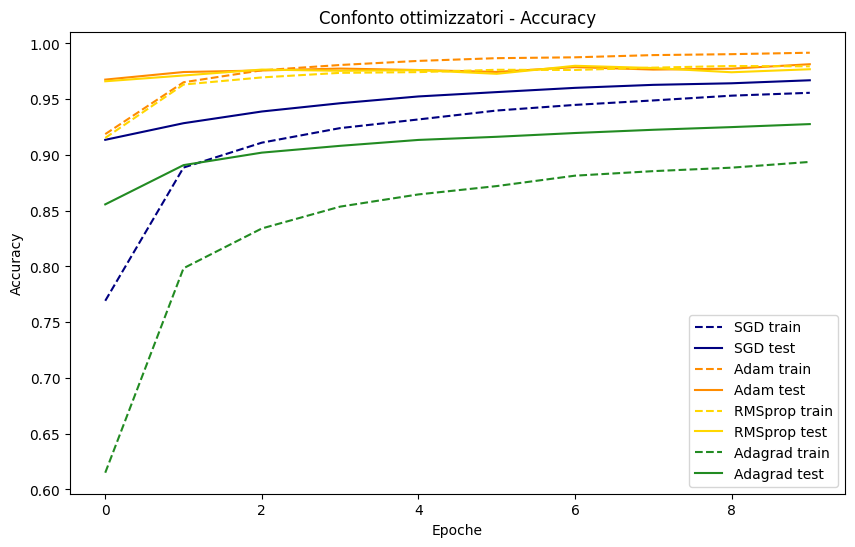

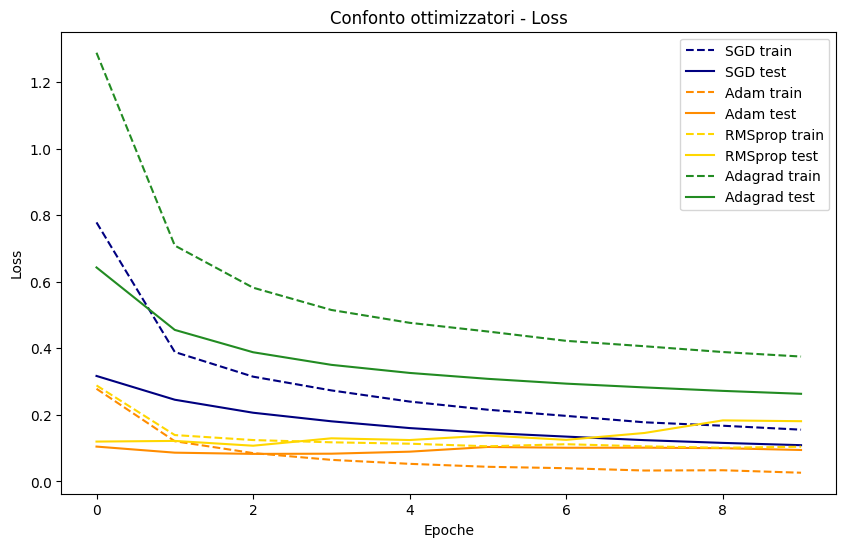

In [42]:
for name in optimizers.keys():
    print(f"{name}")
    print("Test loss:", scores[name][0])
    print("Test accuracy:", scores[name][1])
    print()


colors = {
    list(optimizers.keys())[0]: "navy",
    list(optimizers.keys())[1]: "darkorange",
    list(optimizers.keys())[2]: "gold",
    list(optimizers.keys())[3]: "forestgreen"
}

# ACCURANCY
plt.figure(figsize=(10, 6))
for name in optimizers.keys():
    color = colors[name]
    plt.plot(histories[name].history['acc'],
             color=color,
             linestyle='--',
             label=f'{name} train')
    plt.plot(histories[name].history['val_acc'],
             color=color,
             linestyle='-',
             label=f'{name} test')
plt.title("Confonto ottimizzatori - Accuracy")
plt.xlabel("Epoche")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# LOSS
plt.figure(figsize=(10, 6))
for name in optimizers.keys():
    color = colors[name]
    plt.plot(histories[name].history['loss'],
             color=color,
             linestyle='--',
             label=f'{name} train')
    plt.plot(histories[name].history['val_loss'],
             color=color,
             linestyle='-',
             label=f'{name} test')

plt.title("Confonto ottimizzatori - Loss")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.legend()
plt.show()

Infine, vengono analizzate le predizioni effettuate dai modelli addestrati.

Per ciascun modello addestrato viene generata una previsione sulle immagini del test set tramite il metodo `predict()`: le probabilità restituite dal modello vengono poi convertite nella classe predetta utilizzando l’operazione di argmax, che seleziona l’indice con probabilità massima. Le immagini vengono riportate alla loro forma originale 28×28 pixel e visualizzate insieme alle corrispondenti predizioni.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step

===== SGD =====


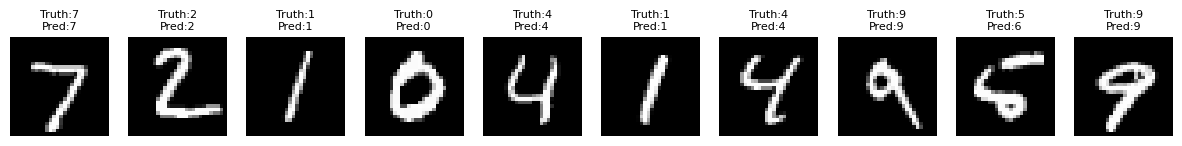

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step

===== Adam =====


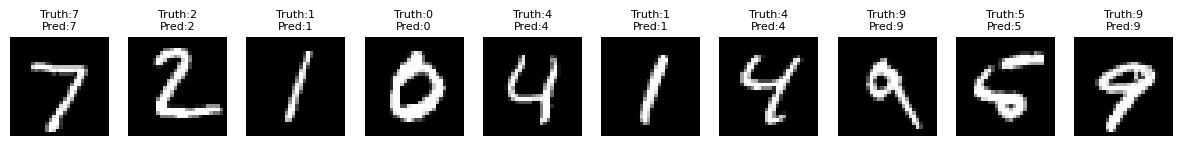

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step

===== RMSprop =====


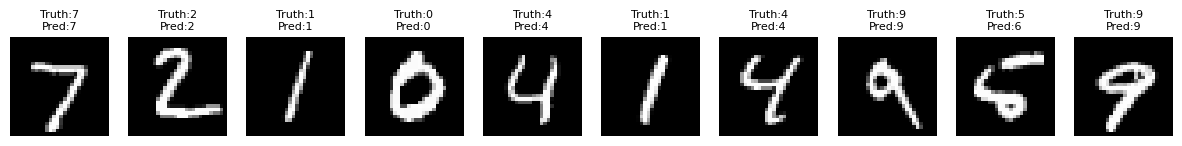

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step

===== Adagrad =====


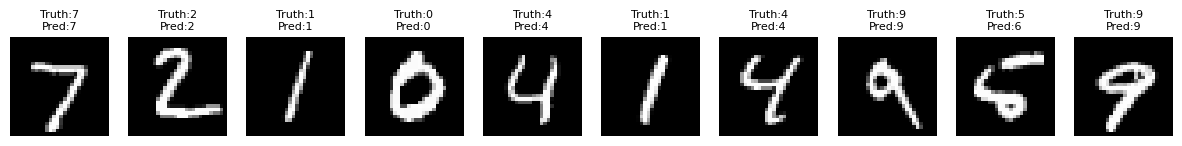

In [14]:
X_test_img = X_test.reshape(-1, img_rows, img_cols)

for name in optimizers.keys():

    model = models[name]
    predictions = model.predict(X_test)

    print(f"\n===== {name} =====")

    plt.figure(figsize=(15, 3))

    for i in range(10):
        plt.subplot(1, 10, i + 1)

        plt.imshow(X_test_img[i], cmap='gray')

        true_label = np.argmax(Y_test[i])
        pred_label = np.argmax(predictions[i])

        plt.title(f"Truth:{true_label}\nPred:{pred_label}", fontsize=8)
        plt.axis('off')

    plt.show()

Dall’analisi dei risultati ottenuti emerge chiaramente una differenza tra i vari ottimizzatori considerati. In particolare, l’ottimizzatore Adam risulta essere il più performante, mostrando una convergenza più rapida e stabile durante il training e raggiungendo i valori di accuracy più elevati sul test set. Al contrario, Adagrad rappresenta l’algoritmo con le prestazioni peggiori, evidenziando una convergenza più lenta e una minore capacità di generalizzazione rispetto agli altri metodi.

Questa conclusione è confermata anche dall’analisi qualitativa delle predizioni sulle immagini di test. In questo caso, si osserva che il modello basato su Adam è l’unico in grado di classificare correttamente anche la penultima immagine del set di esempio, mentre gli altri ottimizzatori commettono errori su tale immagine. Questo risultato evidenzia ulteriormente la maggiore robustezza e affidabilità di Adam rispetto agli altri algoritmi testati.

## **Esercizio 12.2**

In questo esercizio si richiede di modificare l’architettura della rete neurale sviluppata nell’esercizio 12.1, sostituendola con una *Convolutional Neural Network* (CNN). L’obiettivo è migliorare le prestazioni del modello nella classificazione delle immagini del dataset MNIST, sfruttando una struttura più adatta all’elaborazione di dati visivi.

Nel caso della rete precedente (DNN), le immagini venivano trasformate in vettori monodimensionali, perdendo l’informazione spaziale tra i pixel. Le CNN invece operano direttamente su matrici bidimensionali, preservando la struttura dell’immagine e permettendo l’estrazione automatica di caratteristiche significative attraverso operazioni di convoluzione. Per questo motivo, le CNN rappresentano una scelta più efficace per problemi di classificazione di immagini, in quanto sono in grado di apprendere pattern locali (come bordi, forme e contorni) e combinarli progressivamente in rappresentazioni sempre più complesse.

Di seguito sono riportati i principali componenti delle CNN: 
- **Conv2D**: questo strato realizza l'operazione di convoluzione bidimensionale. Esso applica all'immagine una serie di filtri che scorrono su tutta l'immagine: ogni filtro è in grado di riconoscere una particolare caratteristica visiva, come ad esempio bordi orizzontali, bordi verticali o altre strutture geometriche. Durante l'addestramento la rete apprende automaticamente i valori ottimali di questi filtri. L'output di uno strato convoluzionale è costituito da un insieme di mappe delle caratteristiche (*feature maps*), che evidenziano la presenza delle strutture riconosciute dai diversi filtri.
- **MaxPooling2D**: questo ha il compito di ridurre le dimensioni delle mappe delle caratteristiche prodotte dagli strati convoluzionali. L'operazione consiste nel suddividere l'immagine in piccole regioni e sostituire ciascuna regione con il valore massimo contenuto al suo interno. Questo procedimento riduce il numero di parametri da elaborare, diminuisce il costo computazionale e rende la rete meno sensibile a piccole traslazioni o variazioni dell'immagine.
- **Dropout**: è una tecnica di regolarizzazione utilizzata per limitare il fenomeno dell'overfitting. Durante la fase di addestramento una certa frazione di neuroni viene temporaneamente disattivata in modo casuale. In questo modo la rete è costretta a distribuire l'apprendimento tra molti neuroni differenti, evitando di dipendere eccessivamente da specifiche connessioni. Il risultato è generalmente una migliore capacità di generalizzazione sui dati non utilizzati durante l'addestramento.
- **Flatten**: dopo aver estratto le caratteristiche tramite convoluzioni e pooling, i dati sono ancora organizzati come matrici bidimensionali. Dunque, lo strato Flatten converte queste mappe delle caratteristiche in un unico vettore monodimensionale. Questo passaggio è necessario perché gli strati completamente connessi che seguono richiedono un input vettoriale.
- **Dense**: rappresenta un classico strato completamente connesso, analogo a quelli utilizzati nella DNN dell'esercizio precedente. Ogni neurone riceve in ingresso tutte le uscite dello strato precedente. Nelle CNN gli strati Dense vengono generalmente utilizzati nella parte finale della rete, dopo che gli strati convoluzionali hanno già estratto le caratteristiche più importanti dell'immagine. L'ultimo strato Dense utilizza tipicamente la funzione di attivazione softmax, che restituisce le probabilità associate alle diverse classi possibili.

#### STEP 1: DEFINIZIONE DELLA CNN
Innantitutto è stata definita e costruita una Convolutional Neural Network (CNN) utilizzando la libreria Keras, tramite un modello sequenziale (Sequential). La rete è così composta: 
1. Un layer convoluzionale (`Conv2D`) che applica 10 filtri di dimensione 5×5 all’immagine in input. Questo strato ha il compito di iniziare l’estrazione delle caratteristiche fondamentali dell’immagine, come bordi e contorni, utilizzando la funzione di attivazione ReLU per introdurre non linearità.
2. Uno strato di pooling (`MaxPooling2D`) con finestra 2×2 che riduce la dimensione spaziale delle feature maps e rende la rete più robusta a piccole traslazioni o distorsioni dell’immagine.
3. Un secondo strato convoluzionale (`Conv2D`) con con 20 filtri sempre di dimensione 5×5 che approfondisce il processo di estrazione delle caratteristiche.
4. Un secondo layer di pooling (`MaxPooling2D`)
5. Uno strato di regolarizzazione (`Dropout`) con probabilità 0.25 che disattiva casualmente una parte dei neuroni durante l’addestramento e riduce il rischio di overfitting.
6. Uno strato `Flatten` che trasforma le *feature maps* in un vettore monodimensionale, così da poter essere utilizzate dagli strati completamente connessi.
7. Uno strato `Dense` con 128 neuroni e funzione di attivazione ReLU, che combina le caratteristiche estratte per produrre una rappresentazione utile alla decisione finale.
8. Uno secondo strato Dropout (con  probabilità 0.5) per migliorare la generalizzazione del modello.
9. Uno strato di output (layer `Dense`) con un numero di neuroni pari al numero di classi (quindi 10 nel caso di MNIST) e funzione di attivazione softmax, che restituisce una distribuzione di probabilità sulle possibili classi.

Il modello viene quindi compilato utilizzando la funzione di perdita `categorical_crossentropy` e l’ottimizzatore Stochastic Gradient Descent (SGD), con la metrica di valutazione basata sull’accuratezza (accuracy).

In [4]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten

def create_CNN():

    model = Sequential()

    # primo strato convoluzionale
    model.add(
        Conv2D(
            10,
            kernel_size=(5, 5),
            activation='relu',
            input_shape=input_shape
        )
    )

    # pooling
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # secondo strato convoluzionale
    model.add(
        Conv2D(
            20,
            kernel_size=(5, 5),
            activation='relu'
        )
    )

    # pooling
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # dropout
    model.add(Dropout(0.25))

    # passaggio da mappe 2D a vettore
    model.add(Flatten())

    # strato fully connected
    model.add(Dense(128, activation='relu'))

    # dropout
    model.add(Dropout(0.5))

    # output
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer='SGD',
        metrics=['acc']
    )

    return model

#### STEP 2: Preparazione dei dati e training della CNN

Innanzitutto vengono preparate i dati del dataset MINST. Le etichette delle classi vengono convertite in formato one-hot encoding tramite la funzione `to_categorical`: questo passaggio trasforma ogni etichetta numerica in un vettore binario di dimensione 10, necessario per l’utilizzo della funzione di perdita categorical_crossentropy. Successivamente, le immagini vengono riformattate per poter essere utilizzate da una CNN. In particolare, il dataset viene ridimensionato da una struttura bidimensionale (28×28) a una struttura tridimensionale (28×28×1), dove l’ultima dimensione rappresenta il canale dell’immagine (scala di grigi). Questo è richiesto dagli strati convoluzionali di Keras. Le immagini vengono inoltre normalizzate dividendo tutti i valori dei pixel per 255: questo passaggio porta i valori nell’intervallo $[0,1]$. 

Dopo la preparazione dei dati, impostata la fase di training attraverso la scelta dei principali iperparametri: batch size pari a 32 e numero di epoche pari a 10. A questo punto viene creata la CNN tramite la funzione `create_CNN()` e avviato il processo di addestramento mediante il metodo `fit`. Durante il training, il modello apprende i parametri ottimali minimizzando la funzione di perdita sui dati di training e, contemporaneamente, viene monitorata la performance anche sul validation set (X_test, Y_test).

In [5]:
from keras.utils import to_categorical

Y_train = to_categorical(Y_train, 10)
Y_test = to_categorical(Y_test, 10)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
X_train = X_train / 255.0
X_test = X_test / 255.0

input_shape = (28, 28, 1)

batch_size = 32
epochs = 20

model_CNN = create_CNN()

history_CNN = model_CNN.fit(
    X_train,
    Y_train,
    batch_size=batch_size,
    epochs=epochs,
    shuffle=True,
    verbose=1,
    validation_data=(X_test, Y_test)
)

/opt/anaconda3/envs/lab12/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.7221 - loss: 0.8360 - val_acc: 0.9529 - val_loss: 0.1667
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9118 - loss: 0.2910 - val_acc: 0.9674 - val_loss: 0.1082
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9338 - loss: 0.2214 - val_acc: 0.9728 - val_loss: 0.0885
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.9431 - loss: 0.1874 - val_acc: 0.9766 - val_loss: 0.0756
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9498 - loss: 0.1650 - val_acc: 0.9791 - val_loss: 0.0660
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9546 - loss: 0.1490 - val_acc: 0.9817 - val_loss: 0.0598
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9582 - loss: 0.1366 - val_acc: 0.9829 - val_loss: 0.0553
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9603 - loss: 0.1277 - val_acc: 0.9834 - val_loss: 0.0517
Epoch 9/20
1875/1875 ━━━━━━━━━━━

#### STEP 3: ANALISI DEI RISULTATI OTTENUTI
Il modello viene poi valutato quantitativamente sul dataset di test al fine di misurare la sua capacità di generalizzazione su dati mai visti durante il training. La valutazione viene effettuata tramite il metodo `evaluate`, che restituisce due principali metriche, ovvero la loss e l’accuracy.

Successivamente, per analizzare l’andamento del processo di apprendimento nel tempo, vengono visualizzati i grafici di accuracy e loss sia per il training set che per il test set. Questi valori sono stati registrati durante ogni epoca di addestramento e sono contenuti nella variabile `history`. Nel primo grafico viene rappresentata l’evoluzione dell’accuracy in funzione del numero di epoche; nel secondo grafico viene invece mostrato l’andamento della loss.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9895 - loss: 0.0324

Test loss: 0.03242308273911476
Test accuracy: 0.9894999861717224


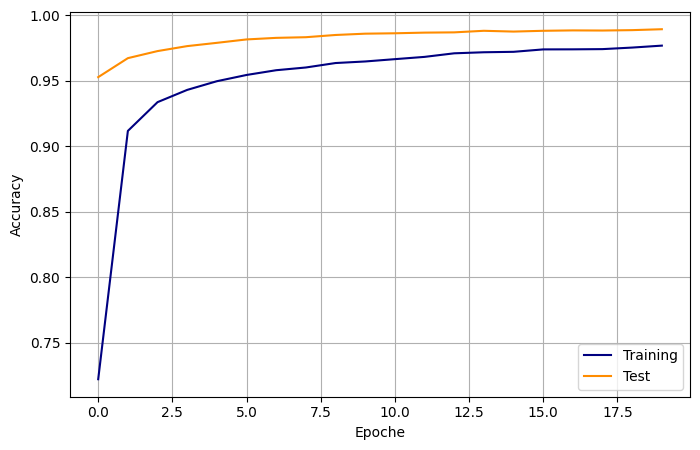

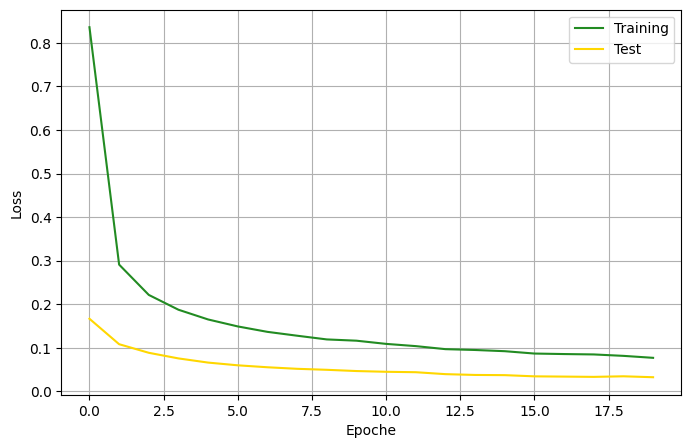

In [6]:
import matplotlib.pyplot as plt

score = model_CNN.evaluate(X_test, Y_test, verbose=1)

print()
print("Test loss:", score[0])
print("Test accuracy:", score[1])

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_CNN.history['acc'], color = 'navy', label='Training')
plt.plot(history_CNN.history['val_acc'], color = 'darkorange', label='Test')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history_CNN.history['loss'], color = 'forestgreen', label='Training')
plt.plot(history_CNN.history['val_loss'], color = 'gold', label='Test')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

Infine, viene effettuata un’analisi qualitativa delle prestazioni della CNN attraverso la visualizzazione diretta di alcune predizioni sul dataset di test. Il modello viene utilizzato per generare le predizioni sulle immagini del test set tramite il metodo `predict`. Per ogni immagine in input, il modello restituisce un vettore di probabilità associato alle dieci classi possibili (ovvero le cifre da 0 a 9). La classe predetta viene quindi determinata selezionando l’indice corrispondente al valore massimo di tale distribuzione, utilizzando la funzione `argmax`.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


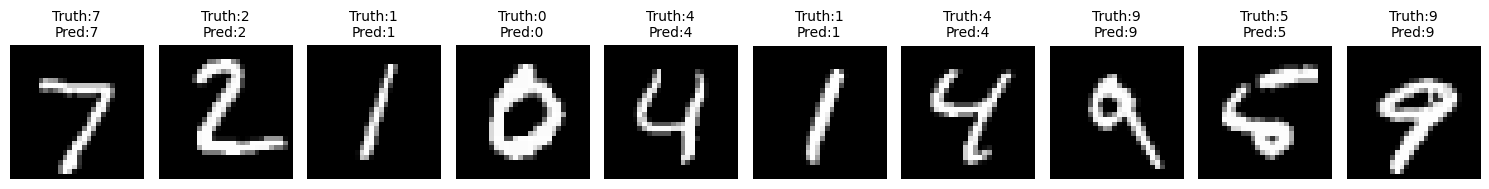

In [11]:
import numpy as np

predictions = model_CNN.predict(X_test)

plt.figure(figsize=(15, 4))

for i in range(10):

    plt.subplot(1, 10, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

    true_label = np.argmax(Y_test[i])
    pred_label = np.argmax(predictions[i])

    plt.title(f"Truth:{true_label}\nPred:{pred_label}", fontsize=10)

plt.tight_layout()
plt.show()

I risultati ottenuti con la Convolutional Neural Network mostrano un miglioramento significativo rispetto alla rete neurale completamente connessa (DNN) utilizzata nell’esercizio precedente. In particolare, la CNN riesce a raggiungere valori di accuracy più elevati sul dataset di test e una loss più contenuta, indicando una migliore capacità di apprendimento e di generalizzazione.

Anche l’analisi qualitativa delle predizioni conferma queste osservazioni: per le immagini considerate, il modello identifica correttamente le cifre del dataset di test. 

## **Esercizio 12.3**

In questo esercizio si vuole testare la capacità di generalizzazione della CNN sviluppata nell’esercizio precedente. In particolare, dopo aver addestrato il modello sul dataset MNIST, sono state create dieci immagini contenenti cifre scritte a mano utilizzando il software GIMP e si testa la capacità della rete di riconoscerle correttamente. L’obiettivo dell’esercizio è quindi valutare se il modello sia in grado di classificare correttamente immagini esterne al dataset di training, caratterizzate da uno stile di scrittura differente.

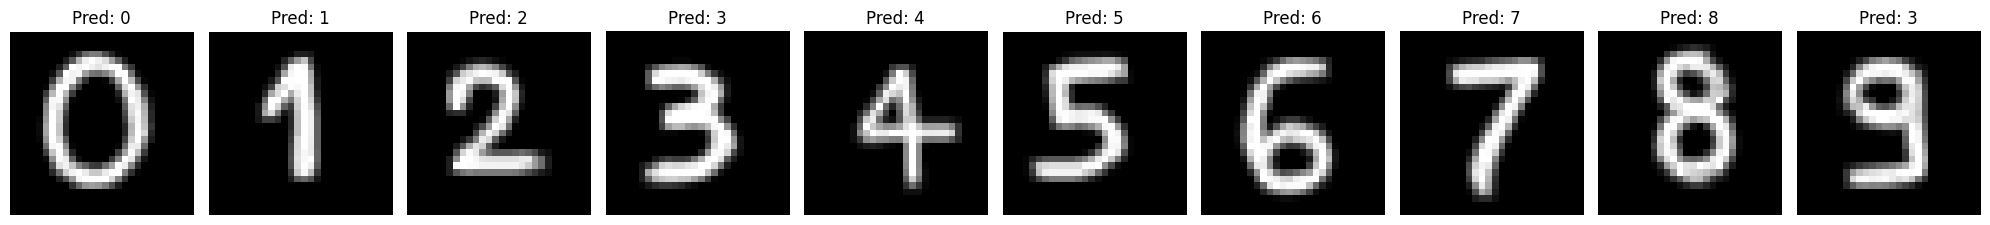

In [20]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

# elenco dei file immagine
image_files = sorted(
    [f for f in os.listdir("Images") if f.endswith(".png")]
)

images = []
predictions = []

for filename in image_files:

    digit_in = Image.open(os.path.join("Images", filename)).convert('L')

    xdim, ydim = digit_in.size

    pix = digit_in.load()
    data = np.zeros((xdim, ydim))

    for j in range(ydim):
        for i in range(xdim):
            data[i, j] = pix[j, i]

    data /= 255.0

    # salvataggio immagine per visualizzazione
    images.append(data.copy())

    # predizione CNN
    data_cnn = data.reshape(1, xdim, ydim, 1)
    pred = model_CNN.predict(data_cnn, verbose=0)

    predictions.append(np.argmax(pred))

# visualizzazione finale
n = len(images)

plt.figure(figsize=(2*n, 3))

for i in range(n):

    plt.subplot(1, n, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(f"Pred: {predictions[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Le predizioni ottenute mostrano che la CNN è in grado di riconoscere correttamente la maggior parte delle cifre scritte manualmente (tutte tranne il 9, che viene interpretato come un 3). Nonostante le immagini utilizzate per il test non appartengano al dataset MNIST e presentino quindi caratteristiche differenti rispetto ai dati di addestramento, il modello riesce comunque a identificare correttamente le forme principali delle cifre.

Questo risultato evidenzia la buona capacità di generalizzazione della rete convoluzionale. Durante il training, infatti, il modello non ha semplicemente memorizzato le immagini presenti nel dataset, ma ha appreso caratteristiche più generali delle cifre, come contorni, curvature e strutture geometriche distintive.